# Movie Review Sentiment Analysis — Model Building & Evaluation

Vectorize the cleaned text with TF-IDF, train 7 classifiers, compare them, run cross-validation, and tune the best performer with GridSearchCV.

## 1. Imports & Load Cleaned Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings; warnings.filterwarnings('ignore')

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.naive_bayes import MultinomialNB, ComplementNB
from sklearn.linear_model import LogisticRegression, RidgeClassifier, PassiveAggressiveClassifier
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier

from utils import evaluate_model, plot_confusion_matrix, compare_models
sns.set_style('whitegrid')
%matplotlib inline

In [2]:
df = pd.read_csv('data/imdb_cleaned.csv').dropna(subset=['clean_text'])
# Subsample to 25,000 reviews (balanced) so single-threaded training
# stays fast; the full 50k is available in imdb_cleaned.csv.
df = df.groupby('label', group_keys=False).sample(n=12500, random_state=42).reset_index(drop=True)
print('Shape:', df.shape)
df.head()

Shape: (25000, 2)


,clean_text,label
0,usual much prefer french movi american one exp...,0
1,movi lack everyth stori act surpris ingenu sou...,0
2,bonjour tristess cover similar ground member w...,0
3,blue desert may potenti even half way plausibl...,0
4,writer director film obvious know anyth film t...,0


## 2. TF-IDF Vectorization & Train/Test Split

In [3]:
X_text = df['clean_text'].astype(str)
y = df['label']
X_train_txt, X_test_txt, y_train, y_test = train_test_split(
    X_text, y, test_size=0.2, random_state=42, stratify=y)
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 1), sublinear_tf=True)
X_train = vectorizer.fit_transform(X_train_txt)
X_test = vectorizer.transform(X_test_txt)
print('TF-IDF train matrix:', X_train.shape)
print('TF-IDF test matrix :', X_test.shape)

TF-IDF train matrix: (20000, 5000)
TF-IDF test matrix : (5000, 5000)


## 3. Train 7 Classifiers

In [4]:
results = []
models = {}


  Multinomial NB
  Accuracy    : 0.8408
  Precision   : 0.8408
  Recall      : 0.8408
  F1 Score    : 0.8408


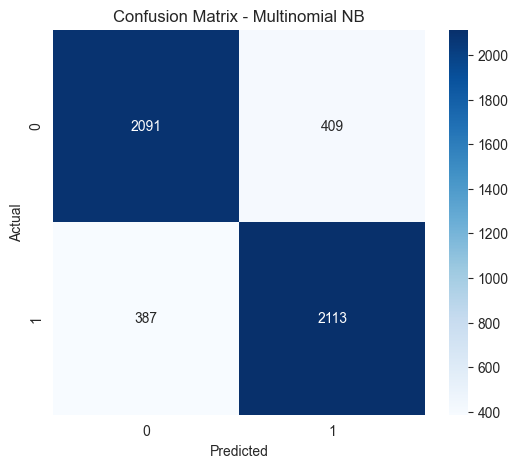

In [5]:
mnb = MultinomialNB()
mnb.fit(X_train, y_train)
y_pred = mnb.predict(X_test)
results.append(evaluate_model('Multinomial NB', y_test, y_pred))
models['Multinomial NB'] = mnb
plot_confusion_matrix(y_test, y_pred, 'Multinomial NB'); plt.show()


  Complement NB
  Accuracy    : 0.8408
  Precision   : 0.8408
  Recall      : 0.8408
  F1 Score    : 0.8408


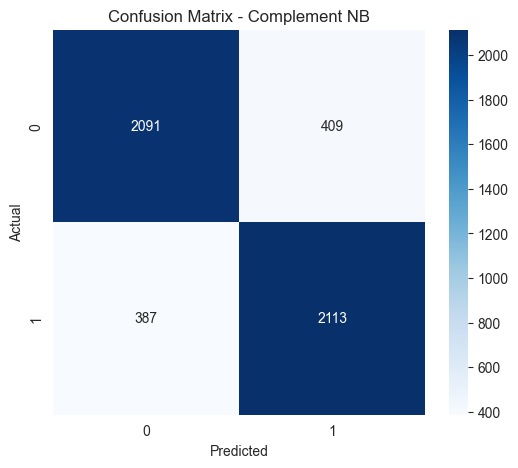

In [6]:
cnb = ComplementNB()
cnb.fit(X_train, y_train)
y_pred = cnb.predict(X_test)
results.append(evaluate_model('Complement NB', y_test, y_pred))
models['Complement NB'] = cnb
plot_confusion_matrix(y_test, y_pred, 'Complement NB'); plt.show()


  Logistic Regression
  Accuracy    : 0.8742
  Precision   : 0.8744
  Recall      : 0.8742
  F1 Score    : 0.8742


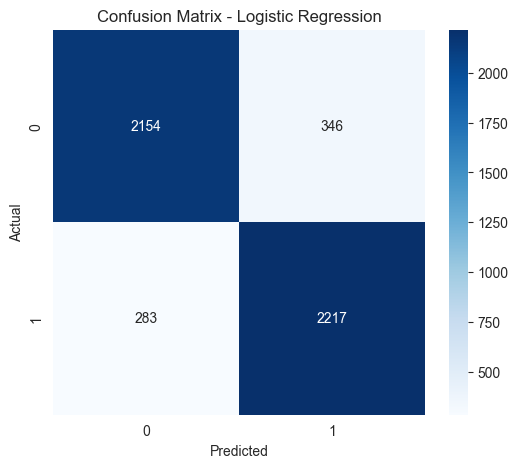

In [7]:
lr = LogisticRegression(max_iter=2000, C=1.0)
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)
results.append(evaluate_model('Logistic Regression', y_test, y_pred))
models['Logistic Regression'] = lr
plot_confusion_matrix(y_test, y_pred, 'Logistic Regression'); plt.show()


  Linear SVM
  Accuracy    : 0.8626
  Precision   : 0.8626
  Recall      : 0.8626
  F1 Score    : 0.8626


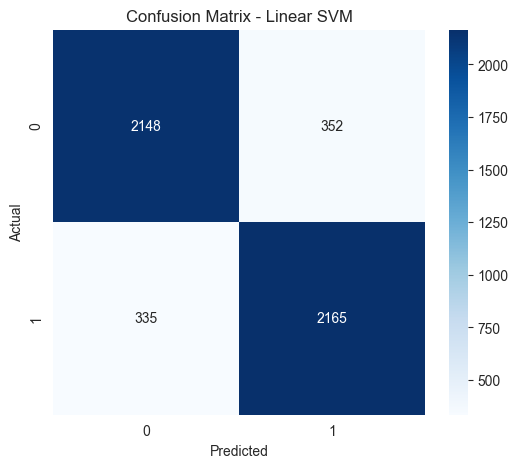

In [8]:
svm = LinearSVC(C=1.0)
svm.fit(X_train, y_train)
y_pred = svm.predict(X_test)
results.append(evaluate_model('Linear SVM', y_test, y_pred))
models['Linear SVM'] = svm
plot_confusion_matrix(y_test, y_pred, 'Linear SVM'); plt.show()


  Ridge Classifier
  Accuracy    : 0.8630
  Precision   : 0.8631
  Recall      : 0.8630
  F1 Score    : 0.8630


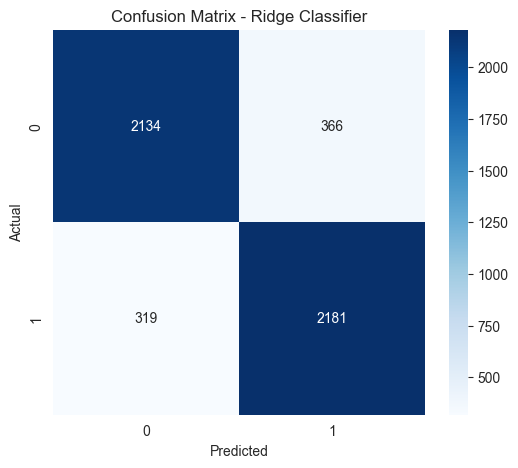

In [9]:
ridge = RidgeClassifier()
ridge.fit(X_train, y_train)
y_pred = ridge.predict(X_test)
results.append(evaluate_model('Ridge Classifier', y_test, y_pred))
models['Ridge Classifier'] = ridge
plot_confusion_matrix(y_test, y_pred, 'Ridge Classifier'); plt.show()


  Passive Aggressive
  Accuracy    : 0.8190
  Precision   : 0.8190
  Recall      : 0.8190
  F1 Score    : 0.8190


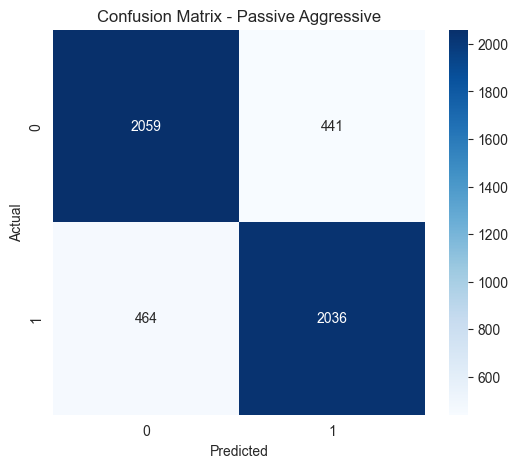

In [10]:
pac = PassiveAggressiveClassifier(max_iter=1000, random_state=42)
pac.fit(X_train, y_train)
y_pred = pac.predict(X_test)
results.append(evaluate_model('Passive Aggressive', y_test, y_pred))
models['Passive Aggressive'] = pac
plot_confusion_matrix(y_test, y_pred, 'Passive Aggressive'); plt.show()


  Random Forest
  Accuracy    : 0.8212
  Precision   : 0.8215
  Recall      : 0.8212
  F1 Score    : 0.8212


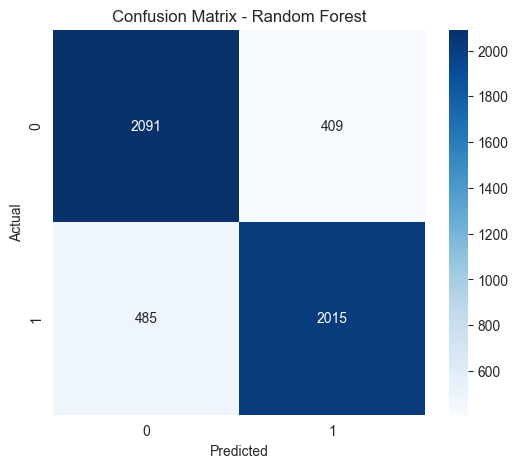

In [11]:
rf = RandomForestClassifier(n_estimators=40, random_state=42, n_jobs=1)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
results.append(evaluate_model('Random Forest', y_test, y_pred))
models['Random Forest'] = rf
plot_confusion_matrix(y_test, y_pred, 'Random Forest'); plt.show()
# Use a single-threaded RF clone for cross-validation to avoid
# nested-parallelism deadlocks (RF n_jobs=1 inside cross_val_score n_jobs=1).
rf_cv = RandomForestClassifier(n_estimators=40, random_state=42, n_jobs=1)

## 4. Model Comparison

In [12]:
comparison = compare_models(results)
comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.8742,0.874438,0.8742,0.874180
1,Ridge Classifier,0.8630,0.863128,0.8630,0.862988
2,Linear SVM,0.8626,0.862617,0.8626,0.862598
3,Multinomial NB,0.8408,0.840826,0.8408,0.840797
4,Complement NB,0.8408,0.840826,0.8408,0.840797
5,Random Forest,0.8212,0.821497,0.8212,0.821159
6,Passive Aggressive,0.8190,0.819027,0.8190,0.818996


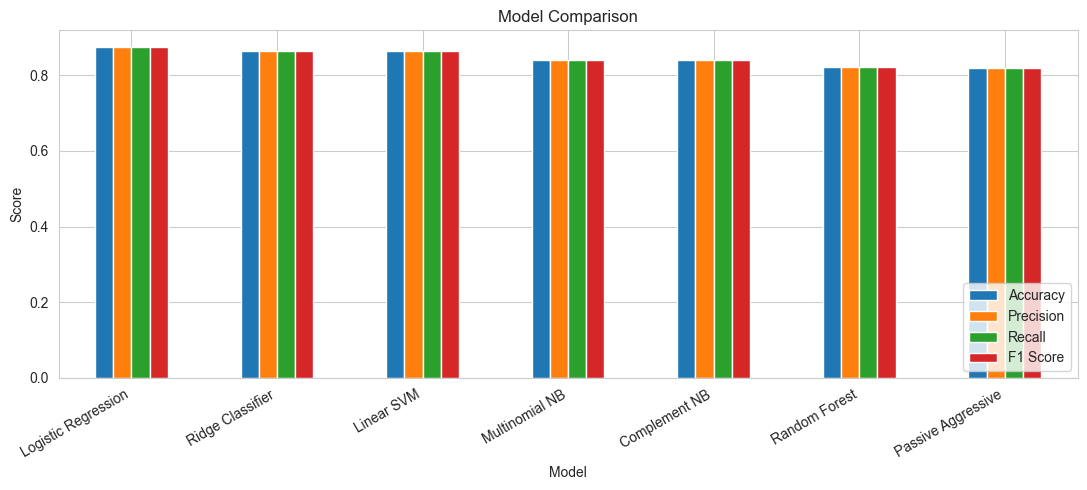

In [13]:
fig, ax = plt.subplots(figsize=(11, 5))
comparison.set_index('Model')[['Accuracy', 'Precision', 'Recall', 'F1 Score']].plot(kind='bar', ax=ax)
ax.set_title('Model Comparison'); ax.set_ylabel('Score')
plt.xticks(rotation=30, ha='right'); plt.legend(loc='lower right'); plt.tight_layout(); plt.show()

## 5. Top Predictive Words (best linear model)

In [14]:
best_linear = models.get('Logistic Regression')
feature_names = np.array(vectorizer.get_feature_names_out())
if best_linear is not None and hasattr(best_linear, 'coef_'):
    coefs = best_linear.coef_
    if coefs.shape[0] == 1:
        top_pos = feature_names[np.argsort(coefs[0])[-15:]]
        top_neg = feature_names[np.argsort(coefs[0])[:15]]
        print('Words pushing toward the positive class:'); print(list(top_pos))
        print('\nWords pushing toward the negative class:'); print(list(top_neg))
    else:
        for ci in range(min(coefs.shape[0], 4)):
            top = feature_names[np.argsort(coefs[ci])[-12:]]
            print(f'Class {ci} top words:', list(top))

Words pushing toward the positive class:
['well', 'entertain', 'brilliant', 'highli', 'hilari', 'today', 'fun', 'favorit', 'amaz', 'best', 'love', 'perfect', 'enjoy', 'excel', 'great']

Words pushing toward the negative class:
['worst', 'wast', 'bad', 'aw', 'bore', 'poor', 'terribl', 'noth', 'wors', 'disappoint', 'fail', 'stupid', 'horribl', 'poorli', 'lame']


## 6. 5-Fold Cross-Validation

In [15]:
cv_idx = np.random.RandomState(42).choice(len(X_text), size=min(len(X_text), 6000), replace=False)
X_cv_text = X_text.iloc[cv_idx]
y_cv = y.iloc[cv_idx]
X_all = vectorizer.fit_transform(X_cv_text)
cv_scores = {}
for name, model in models.items():
    # swap in the single-threaded RF clone to avoid nested-parallelism hangs
    cv_model = rf_cv if name == 'Random Forest' else model
    scores = cross_val_score(cv_model, X_all, y_cv, cv=5, scoring='f1_weighted', n_jobs=1)
    cv_scores[name] = scores
    print(f'{name:22s} mean F1 = {scores.mean():.4f} (+/- {scores.std():.4f})')

Multinomial NB         mean F1 = 0.8372 (+/- 0.0136)
Complement NB          mean F1 = 0.8365 (+/- 0.0131)


Logistic Regression    mean F1 = 0.8681 (+/- 0.0051)


Linear SVM             mean F1 = 0.8488 (+/- 0.0079)


Ridge Classifier       mean F1 = 0.8535 (+/- 0.0055)


Passive Aggressive     mean F1 = 0.8292 (+/- 0.0110)


Random Forest          mean F1 = 0.8136 (+/- 0.0078)


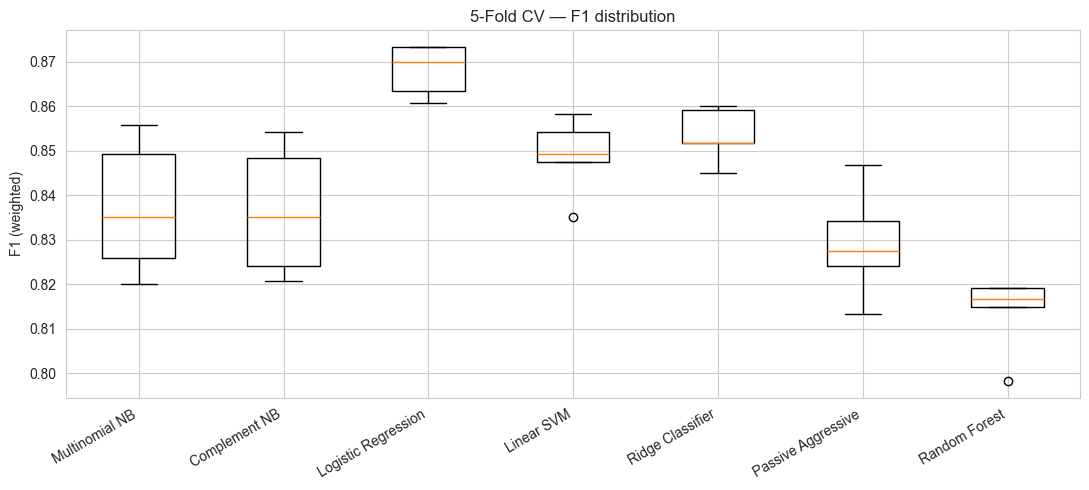

In [16]:
plt.figure(figsize=(11, 5))
plt.boxplot([cv_scores[k] for k in cv_scores], labels=list(cv_scores.keys()))
plt.xticks(rotation=30, ha='right'); plt.ylabel('F1 (weighted)')
plt.title('5-Fold CV — F1 distribution'); plt.tight_layout(); plt.show()

## 7. Hyperparameter Tuning — Best Performer

Best params: {'clf__C': 1.0, 'tfidf__ngram_range': (1, 1)}
Best CV F1: 0.8804



  Logistic Regression (Tuned)
  Accuracy    : 0.8742
  Precision   : 0.8744
  Recall      : 0.8742
  F1 Score    : 0.8742


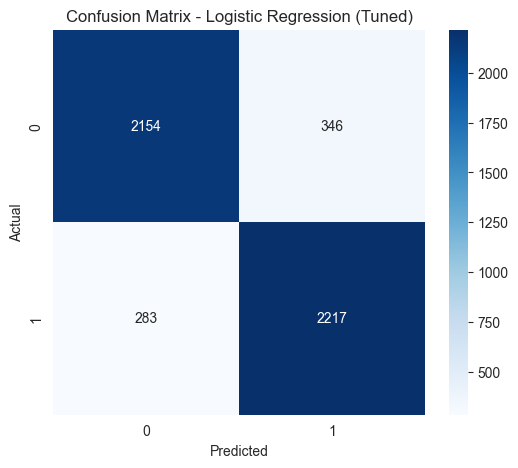

In [17]:
# Tune Logistic Regression over C and TF-IDF ngram range via a small grid
from sklearn.pipeline import Pipeline
pipe = Pipeline([
    ('tfidf', TfidfVectorizer(sublinear_tf=True, max_features=5000)),
    ('clf', LogisticRegression(max_iter=2000)),
])
param_grid = {
    'tfidf__ngram_range': [(1, 1)],
    'clf__C': [1.0, 10.0],
}
grid = GridSearchCV(pipe, param_grid, cv=3, scoring='f1_weighted', n_jobs=1, verbose=0)
grid.fit(X_train_txt, y_train)
print('Best params:', grid.best_params_)
print('Best CV F1:', round(grid.best_score_, 4))
best = grid.best_estimator_
y_pred = best.predict(X_test_txt)
tuned_metrics = evaluate_model('Logistic Regression (Tuned)', y_test, y_pred)
results.append(tuned_metrics)
plot_confusion_matrix(y_test, y_pred, 'Logistic Regression (Tuned)'); plt.show()

## 8. Sample Predictions

In [18]:
sample_idx = X_test_txt.index[:6]
best_model = models[comparison.iloc[0]['Model']]
sample_pred = best_model.predict(vectorizer.transform(X_test_txt.loc[sample_idx]))
out = pd.DataFrame({
    'text_excerpt': X_test_txt.loc[sample_idx].str.slice(0, 80).values,
    'predicted': sample_pred,
    'actual': y_test.loc[sample_idx].values,
})
out

,text_excerpt,predicted,actual
0,henri fool better film perfect way follow film...,1,1
1,could watch movi day love probabl time favorit...,1,1
2,drink water unbeliev bad film base broadway pl...,1,0
3,sky captain world tomorrow amazingli incoveni ...,0,0
4,brown harvard hard movi pin expect lot movi da...,1,1
5,bad anim look terribl look like ps type game a...,0,0


## 9. Final Summary

In [19]:
final = compare_models(results)
final

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.8742,0.874438,0.8742,0.874180
1,Logistic Regression (Tuned),0.8742,0.874438,0.8742,0.874180
2,Ridge Classifier,0.8630,0.863128,0.8630,0.862988
3,Linear SVM,0.8626,0.862617,0.8626,0.862598
4,Multinomial NB,0.8408,0.840826,0.8408,0.840797
5,Complement NB,0.8408,0.840826,0.8408,0.840797
6,Random Forest,0.8212,0.821497,0.8212,0.821159
7,Passive Aggressive,0.8190,0.819027,0.8190,0.818996


### Key Takeaways

- Movie Review Sentiment Analysis: text classification with TF-IDF features.
- 7 classifiers + 1 tuned variant evaluated on accuracy / precision / recall / F1 (weighted).
- Linear models (Logistic Regression, Linear SVM) and Naive Bayes dominate on sparse TF-IDF features.
- Cross-validation confirms whether the ranking is stable.

### Next Steps

- Try word embeddings (word2vec, GloVe) or transformer models (BERT) for richer representations.
- Add character n-grams for robustness to spelling variation.
- Calibrate probabilities if downstream decisions need confidence scores.